In [64]:
PP[u_, v_, Q_] := ((1-u)(u^2+A^2)-Q*u*v)u^2;
QQ[u_, v_, B_] := B(u-v)(u^2+A^2)v;

In [66]:
h1[u_, v_] = PP[u + H, v + H, Q] ;
h2[u_, v_] = QQ[u + H, v + H, B] ;
F1[u_, v_] = h1[u, v] - a*u - b*v ;
F2[u_, v_] = h2[u, v] - a*u + a*v ;
G1[u_, v_] = (1/d)(F1[u, v] - F2[u, v]);
G2[u_, v_] = F2[u, v];

2           2                                   2    2
 H  (m + n - H  Q)   (a + b - 3 H m - 4 H n - 2 (A  - H  + n) Q) Y
(----------------- - --------------------------------------------- + 
         d                                 d
 
          2                 2               2     2                          3
      (3 A  + 6 m + 13 n + H  (-1 - 12 Q)) Y    (A  + 2 H (-2 + 5 H + 2 Q)) Y        4
>     --------------------------------------- - ------------------------------ + O[Y] )\
                        2 d                                   d
 
              2                  2
>    + (-(H (A  B - 3 m - 4 n + H  (B + 3 Q))) + 
 
         2                         2
>      (A  (3 - B) + 6 m + 13 n - H  (1 + 3 B + 9 Q)) Y - 
 
           2                             2                         3       4
>      3 (A  + H (-4 + B + 10 H + 3 Q)) Y  + (4 - B - 20 H - 3 Q) Y  + O[Y] ) X + 
 
           2                 2
     d (3 A  + 6 m + 13 n - H  (1 + 4 B + 6 Q))
>   (------------------------------------------ - 
                         2
 
             2                                                              2
>      d (3 A  + 4 B H + 6 H (-2 + 5 H + Q)) Y - d (-6 + 2 B + 30 H + 3 Q) Y  - 
 
             3       4   2       2   2
>      10 d Y  + O[Y] ) X  + (-(d  (A  + H (-4 + B + 10 H + Q))) - 
 
        2                             2  2       4   3       4
>      d  (-4 + B + 20 H + Q) Y - 10 d  Y  + O[Y] ) X  + O[X]
                   2    2           2      2               2        3       4
((-(a d) + B d H (A  + H )) + B d (A  + 3 H ) Y + 3 B d H Y  + B d Y  + O[Y] ) X + 
 
          2  2        2            2  2       4   2       3        3         4   3
>   (2 B d  H  + 4 B d  H Y + 2 B d  Y  + O[Y] ) X  + (B d  H + B d  Y + O[Y] ) X  + 
 
        4
>   O[X]
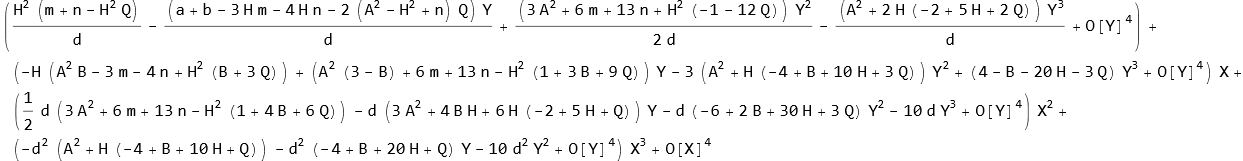

In [72]:
asumir = {a > 0, b < 0, d > 0, m > 0, n > 0, 0 < A < (H* Sqrt[1 - 2*H]), B > 0,  0 < H < (1/2), Q > 0};

restricciones = {
  m == H^3 + A^2*(2 - H),
  n == H^2*(1 - 2*H) - A^2,
  A^2 + H^2 == (m + n)/(1 - H)
};

simplificarMN[expr_] := FullSimplify[
   expr, 
   restricciones, 
   Assumptions -> asumir
];

expansionG1 = simplificarMN[Series[G1[d*X + Y, Y], {X, 0, 3}, {Y, 0, 3}]]
expansionG2 = simplificarMN[Series[G2[d*X + Y, Y], {X, 0, 3}, {Y, 0, 3}]]
G1SerieTaylor = Normal[expansionG1];
G2SerieTaylor = Normal[expansionG2];

2                 2
d (3 A  + 6 m + 13 n - H  (1 + 4 B + 6 Q))
   2                 2
3 A  + 6 m + 13 n - H  (1 + 12 Q)
---------------------------------
                d
   2                           2
-(A  (-3 + B)) + 6 m + 13 n - H  (1 + 3 B + 9 Q)
    2   2
-6 d  (A  + H (-4 + B + 10 H + Q))
     2
-6 (A  + H (-4 + B + 10 H + 3 Q))
     2  2
4 B d  H
0
      2      2
B d (A  + 3 H )
     2
8 B d  H
0
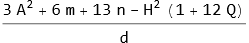

In [79]:
G1xx  = FullSimplify[2  * SeriesCoefficient[G1SerieTaylor, {X,0,2}, {Y,0,0}]]
G1yy  = FullSimplify[2  * SeriesCoefficient[G1SerieTaylor, {X,0,0}, {Y,0,2}]]
G1xy  = FullSimplify[1  * SeriesCoefficient[G1SerieTaylor, {X,0,1}, {Y,0,1}]]
G1xxx = FullSimplify[6  * SeriesCoefficient[G1SerieTaylor, {X,0,3}, {Y,0,0}]]
G1xyy = FullSimplify[2  * SeriesCoefficient[G1SerieTaylor, {X,0,1}, {Y,0,2}]]

G2xx  = FullSimplify[2  * SeriesCoefficient[G2SerieTaylor, {X,0,2}, {Y,0,0}]]
G2yy  = FullSimplify[2  * SeriesCoefficient[G2SerieTaylor, {X,0,0}, {Y,0,2}]]
G2xy  = FullSimplify[1  * SeriesCoefficient[G2SerieTaylor, {X,0,1}, {Y,0,1}]]
G2xxy = FullSimplify[2  * SeriesCoefficient[G2SerieTaylor, {X,0,2}, {Y,0,1}]]
G2yyy = FullSimplify[6  * SeriesCoefficient[G2SerieTaylor, {X,0,0}, {Y,0,3}]]

In [89]:
B = (H^2(1 - 2H) - A^2)/(A^2 + H^2);
Q = (1 - H)(A^2 + H^2)/H^2;
a = H(H^{2}(1-2H)-A^2);
b = -H((1-H)(A^2+H^2));
d = Sqrt[(H^3+A^2(2-H))/(H^2(1-2H) - A^2)];
m = H^3 + A^2*(2 - H);
n = H^2*(1 - 2*H) - A^2;
omega = H Sqrt[m*n];

coeficientelyapunov = (1/16) * (
  (G1xxx + G1xyy + G2xxy + G2yyy) +
  (1/omega) * (G1xy*(G1xx + G1yy) - G2xy*(G2xx + G2yy) - G1xx*G2xx + G1yy*G2yy)
);

l1[a_, h_] := coeficientelyapunov /. {A -> a, H -> h};
Table[
  Module[{h, maxa, a},
    h = RandomReal[{0.001, 0.499}];
    maxa = Sqrt[h^2 (1 - 2 h)];
    a = RandomReal[{0.001, maxa}];
    {a, h, l1[a, h]}
  ],
  {10}
]

l1[0.12, 0.16]

{{0.0861054, 0.181704, -0.0309035}, {0.137429, 0.446271, -1.86168}, 
 
>   {0.190779, 0.341367, -7.63534}, {0.0719331, 0.115575, -0.00275575}, 
 
>   {0.00246777, 0.326957, -0.0000484073}, {0.0486792, 0.409296, -0.0252921}, 
 
>   {0.0584628, 0.0689291, 0.0874496}, {0.0601354, 0.111887, -0.00693613}, 
 
>   {0.0868199, 0.21914, -0.0398811}, {0.00295449, 0.285861, -0.0000690753}}
0.00342862

In [101]:
FullSimplify[coeficientelyapunov > 0, asumir]
Clear[a, b, d, m, n, A, B, H, Q];

5    4                         2  3
(-3 + H) H  + A  (4 + 3 (-3 + H) H) > 4 A  H

In [103]:
FullSimplify[G1xx > 0, asumir]
FullSimplify[G1yy > 0, asumir]
FullSimplify[G1xy > 0, asumir]
FullSimplify[G1xxx > 0, asumir]
FullSimplify[G1xyy > 0, asumir]

FullSimplify[G2xx > 0, asumir]
FullSimplify[G2xy > 0, asumir]
FullSimplify[G2xxy > 0, asumir]

2                 2
3 A  + 6 m + 13 n > H  (1 + 4 B + 6 Q)
   2                 2
3 A  + 6 m + 13 n > H  (1 + 12 Q)
              2             2
6 m + 13 n > A  (-3 + B) + H  (1 + 3 B + 9 Q)
 2
A  + H (-4 + B + 10 H + Q) < 0
 2
A  + H (-4 + B + 10 H + 3 Q) < 0
True
True
True

In [111]:
B = (H^2(1 - 2H) - A^2)/(A^2 + H^2);
Q = (1 - H)(A^2 + H^2)/H^2;
a = H(H^{2}(1-2H)-A^2);
b = -H((1-H)(A^2+H^2));
d = Sqrt[(H^3+A^2(2-H))/(H^2(1-2H) - A^2)];
m = H^3 + A^2*(2 - H);
n = H^2*(1 - 2*H) - A^2;

FullSimplify[G1xx > 0, asumir]
FullSimplify[G1yy > 0, asumir]
FullSimplify[G1xy > 0, asumir]
FullSimplify[G1xxx > 0, asumir]
FullSimplify[G1xyy > 0, asumir]

FullSimplify[G2xx > 0, asumir]
FullSimplify[G2xy > 0, asumir]
FullSimplify[G2xxy > 0, asumir]

Clear[a, b, d, m, n, A, B, H, Q];

4    4               2  2
2 A  + H  (-1 + 3 H) + A  H  (-3 + 7 H) < 0
False
False
   2            2              4    4
3 A  (1 - 3 H) H  + (2 - 7 H) H  > A
False
True
True
True

Legended[Legended[-Graphics-, Placed[SwatchLegend[{Directive[EdgeForm[Directive[
 
>          AbsoluteThickness[2.], Dashing[{Small, Small}], GrayLevel[0.5]]], 
 
>        AbsoluteThickness[2.], Opacity[0.15], GrayLevel[0.5]]}, 
 
>      {Restricciones del Sistema}, LegendMarkers -> Automatic, LabelStyle -> {}, 
 
>      LegendLayout -> Column], After, Identity]], 
 
>   Placed[LineLegend[{Directive[AbsoluteThickness[2], Thickness[0.006], GrayLevel[0]]}, 
 
>     {L_1 = 0}, LegendMarkers -> None, LabelStyle -> {}, LegendLayout -> Column], 
 
>    After, Identity]]
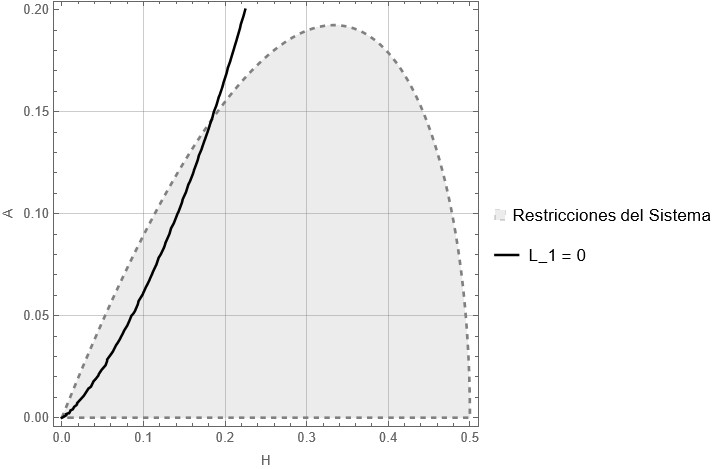

In [1]:
ecuacionL1 = (3H(3-H)-4)A^4 + 4H^3A^2 + (3-H)H^5  == 0;

regionValida = H < 1/2 && A^2 < H^2*(1 - 2*H);

plot = Show[
  RegionPlot[regionValida, {H, 0, 0.5}, {A, 0, 0.2}, 
    PlotStyle -> Directive[Opacity[0.15], Gray], 
    BoundaryStyle -> Directive[Dashed, Gray],
    PlotLegends -> {"Restricciones del Sistema"}
  ],
  ContourPlot[Evaluate[ecuacionL1], {H, 0, 0.5}, {A, 0, 0.2}, 
    ContourStyle -> {Thickness[0.006], Black},
    PlotLegends -> {"L_1 = 0"}
  ],
  
  FrameLabel -> {"H", "A"},
  GridLines -> Automatic
]

In [4]:
Export["CurvaLyapunovAH.pdf", plot]

CurvaLyapunovAH.pdf

In [131]:
polyLyapunov = A^4*(3*H^2 + 4) + H^6 - A^2*(4*H^3 + 9*A^2);

polQ = (1 - H)*(A^2 + H^2) - Q*H^2;

curvaEnAQ = Resultant[polyLyapunov, polQ, H];

curvaEnAQSimplificada = FullSimplify[curvaEnAQ] == 0

8      8              6      6
-(A  (32 A  - 25 (-1 + Q)  + 8 A  (22 - 3 (-8 + Q) Q) + 
 
            2         3
>        2 A  (-1 + Q)  (-22 + 15 Q (5 + Q)) + 
 
            4
>        2 A  (129 + Q (240 + Q (-48 + Q (-68 + 3 Q)))))) == 0

-Graphics-
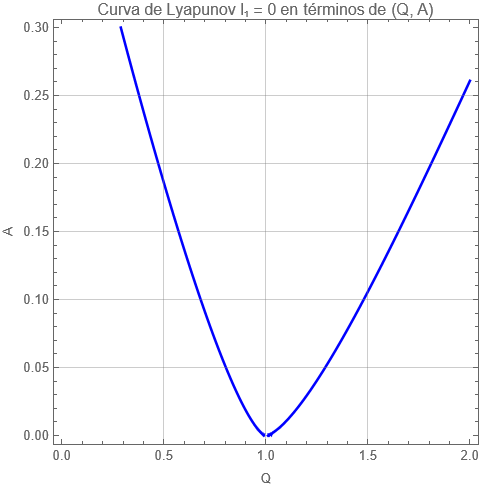

In [138]:
plot1 = ContourPlot[
  Evaluate[curvaEnAQSimplificada], 
  {Q, 0, 2}, {A, 0, 0.3}, (* Ajusta el rango de Q según necesites *)
  PlotPoints -> 100,
  MaxRecursion -> 4,
  ContourStyle -> {Thickness[0.006], Blue},
  FrameLabel -> {"Q", "A"},
  PlotLabel -> "Curva de Lyapunov l₁ = 0 en términos de (Q, A)",
  GridLines -> Automatic
]

In [142]:
Export["CurvaLyapunovAQ.pdf", plot1]

CurvaLyapunovAQ.pdf

In [140]:
CopyToClipboard[ToString[TeXForm[expresion]]]